# Agent Trace Quality, SLO and ROI Model - Observability Tutorial

Implements and extends the model from "Your AI Agent Needs Receipts:
Observability for the Era of Trust Me, I Did It."

This version adds three things beyond the article's original scope:

1. A time series layer: daily aggregated trace metrics over a quarter,
   with a simulated observability rollout changepoint so the data shows
   both a degrading regime and an improving regime.
2. A quantitative finance layer: an incident cost avoidance model and a
   discounted ROI and breakeven calculation, answering the question how
   does better observability turn into money from the buyer side, plus a
   simple usage based pricing model from the vendor side.
3. A statistical process control layer, an EWMA control chart, for
   flagging when the daily error rate moves out of control instead of
   eyeballing a line chart.

Named functions: generate_trace_fixture(), trace_quality(), as specified
in the article, plus simulate_daily_metrics(), ewma_control_chart(),
incident_cost_model(), observability_roi(), and pricing_tiers().

In [1]:
from __future__ import annotations

import sys
import json
import math
from dataclasses import dataclass, field
from pathlib import Path
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline") if "get_ipython" in dir() else None
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent / "shared"))
import yariverse_common as yc

OUT = HERE / "notebook_output"
OUT.mkdir(exist_ok=True)
RUN_ID = "agent-observability-" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
print("Run ID:", RUN_ID)

Run ID: agent-observability-20260918T030533Z


## 1. Evidence: sourced facts vs. model assumptions

Sourced facts go in source_data.csv with a date and URL. Everything the
source article did not report, the fixture size, the SLO target, every
dollar figure in the monetization model, goes in model_assumptions.csv as
an editable, clearly labeled input.

In [2]:
SOURCE_URL = "https://opentelemetry.io/docs/concepts/signals/traces/"

source_data = pd.DataFrame([
    {"label": "Trace Structure", "value": 1, "unit": "trace contains spans",
     "date": "current documentation", "url": SOURCE_URL},
    {"label": "Span Parent Link", "value": 1, "unit": "parent-child relationship",
     "date": "current documentation", "url": SOURCE_URL},
    {"label": "Signals", "value": "traces|metrics|logs|baggage|profiles",
     "unit": "documented signal families", "date": "current documentation", "url": SOURCE_URL},
])
source_data.to_csv(OUT / "source_data.csv", index=False)
source_hash = yc.sha256_file(OUT / "source_data.csv")
source_data

,label,value,unit,date,url
0,Trace Structure,1,trace contains spans,current documentation,https://opentelemetry.io/docs/concepts/signals...
1,Span Parent Link,1,parent-child relationship,current documentation,https://opentelemetry.io/docs/concepts/signals...
2,Signals,traces|metrics|logs|baggage|profiles,documented signal families,current documentation,https://opentelemetry.io/docs/concepts/signals...


In [3]:
model_assumptions = pd.DataFrame([
    {"name": "n_traces", "value": 12, "description": "Number of synthetic agent traces to generate for the single batch fixture"},
    {"name": "min_spans_per_trace", "value": 3, "description": "Minimum spans per trace"},
    {"name": "max_spans_per_trace", "value": 7, "description": "Maximum spans per trace"},
    {"name": "span_names", "value": "plan,retrieve,model_call,tool_call,approve",
     "description": "Illustrative span name vocabulary, mirrors the article's trace waterfall diagram"},
    {"name": "base_error_rate", "value": 0.06, "description": "Illustrative per span baseline error probability, single batch fixture"},
    {"name": "slo_target_success_rate", "value": 0.97, "description": "Illustrative SLO, required success rate"},
    {"name": "seed", "value": 42, "description": "RNG seed for deterministic fixture generation"},
    {"name": "n_days", "value": 90, "description": "Length of the simulated daily time series, one quarter"},
    {"name": "rollout_day", "value": 55, "description": "Day the simulated observability rollout begins improving reliability"},
    {"name": "traces_per_day_mean", "value": 4200, "description": "Illustrative average daily agent run volume"},
    {"name": "pre_rollout_error_rate", "value": 0.085, "description": "Illustrative daily error rate before the rollout"},
    {"name": "post_rollout_error_rate", "value": 0.028, "description": "Illustrative daily error rate after the rollout stabilizes"},
    {"name": "pre_rollout_p95_ms", "value": 2100, "description": "Illustrative p95 end to end latency before the rollout, milliseconds"},
    {"name": "post_rollout_p95_ms", "value": 1150, "description": "Illustrative p95 end to end latency after the rollout, milliseconds"},
    {"name": "cost_per_incident_usd", "value": 3200, "description": "Illustrative fully loaded cost of one production incident, engineering time plus customer impact"},
    {"name": "incident_rate_per_failed_trace", "value": 0.02, "description": "Illustrative probability a failed trace escalates into a full incident rather than a silent retry"},
    {"name": "engineer_hourly_cost_usd", "value": 95, "description": "Illustrative fully loaded engineer hourly cost"},
    {"name": "debug_hours_saved_per_incident", "value": 6, "description": "Illustrative engineering hours saved per incident once traces have receipts instead of guesswork"},
    {"name": "tooling_monthly_cost_usd", "value": 4500, "description": "Illustrative monthly cost of the observability stack, collector plus storage plus dashboards"},
    {"name": "upfront_engineering_cost_usd", "value": 40000, "description": "Illustrative one time cost to instrument the agent and stand up the pipeline"},
    {"name": "annual_discount_rate", "value": 0.12, "description": "Illustrative discount rate used for the ROI schedule"},
    {"name": "evaluation_months", "value": 18, "description": "ROI evaluation horizon in months"},
    {"name": "price_per_million_spans_usd", "value": 180, "description": "Illustrative vendor list price per million spans ingested"},
    {"name": "price_tier_discounts", "value": "0:1.0,10:0.85,50:0.70,200:0.55",
     "description": "Illustrative volume discount schedule, million spans per month to price multiplier"},
])
model_assumptions.to_csv(OUT / "model_assumptions.csv", index=False)
w = model_assumptions.set_index("name")["value"]
model_assumptions

,name,value,description
0,n_traces,12,Number of synthetic agent traces to generate f...
1,min_spans_per_trace,3,Minimum spans per trace
2,max_spans_per_trace,7,Maximum spans per trace
3,span_names,"plan,retrieve,model_call,tool_call,approve","Illustrative span name vocabulary, mirrors the..."
4,base_error_rate,0.06,Illustrative per span baseline error probabili...
5,slo_target_success_rate,0.97,"Illustrative SLO, required success rate"
6,seed,42,RNG seed for deterministic fixture generation
7,n_days,90,"Length of the simulated daily time series, one..."
8,rollout_day,55,Day the simulated observability rollout begins...
9,traces_per_day_mean,4200,Illustrative average daily agent run volume


## 2. The core model: generate_trace_fixture() and trace_quality()

Same method as the article: a deterministic, seeded set of synthetic
traces and spans, scored for completeness, latency, error rate and an
SLO burn rate.

In [4]:
@dataclass
class TraceFixtureConfig:
    """Typed configuration for one synthetic trace batch. Using a dataclass
    instead of loose keyword arguments keeps the function signature stable
    as the model grows, and makes every assumption inspectable as an
    object rather than five positional floats."""
    n_traces: int
    min_spans: int
    max_spans: int
    span_names: list[str]
    base_error_rate: float
    seed: int

    def validate(self) -> None:
        if self.n_traces <= 0:
            raise ValueError("n_traces must be positive")
        if self.min_spans <= 0 or self.max_spans < self.min_spans:
            raise ValueError("invalid span range, need 0 < min_spans <= max_spans")
        if not (0.0 <= self.base_error_rate <= 1.0):
            raise ValueError("base_error_rate must be in [0, 1]")


_SPAN_BASE_DURATION_MS = {
    "plan": 400, "retrieve": 250, "model_call": 900, "tool_call": 600, "approve": 150,
}


def generate_trace_fixture(config: TraceFixtureConfig) -> pd.DataFrame:
    """Deterministic synthetic trace and span fixture. Every span carries
    trace_id, span_id, parent_span_id, name, duration_ms, status, model,
    cost_usd, so the completeness check downstream has something real to
    check against."""
    config.validate()
    rng = np.random.default_rng(config.seed)
    rows = []
    for t in range(config.n_traces):
        trace_id = f"trace_{t:03d}"
        n_spans = rng.integers(config.min_spans, config.max_spans + 1)
        chosen_names = rng.choice(config.span_names, size=n_spans, replace=True)
        parent = None
        for s, name in enumerate(chosen_names):
            span_id = f"{trace_id}_span_{s}"
            base_duration = _SPAN_BASE_DURATION_MS.get(name, 300)
            duration_ms = max(5.0, rng.normal(base_duration, base_duration * 0.35))
            if rng.random() < 0.03:
                duration_ms *= rng.uniform(4, 9)
            status = "error" if rng.random() < config.base_error_rate else "ok"
            rows.append({
                "trace_id": trace_id, "span_id": span_id, "parent_span_id": parent,
                "name": name, "duration_ms": duration_ms, "status": status,
                "model": rng.choice(["model-a", "model-b"]),
                "cost_usd": round(float(rng.uniform(0.001, 0.05)), 5),
            })
            parent = span_id
    return pd.DataFrame(rows)


def trace_quality(spans: pd.DataFrame, required_fields: list[str], slo_target_success_rate: float) -> dict:
    """Completeness, per span p95 latency and error rate, an error budget
    burn number, and a MAD based latency outlier flag."""
    completeness = {f: float(spans[f].notna().mean()) for f in required_fields}

    rollup = spans.groupby("name").agg(
        count=("span_id", "count"),
        p95_latency_ms=("duration_ms", lambda s: np.percentile(s, 95)),
        error_rate=("status", lambda s: (s == "error").mean()),
    ).reset_index()

    trace_status = spans.groupby("trace_id")["status"].apply(lambda s: "error" if (s == "error").any() else "ok")
    observed_success_rate = float((trace_status == "ok").mean())
    observed_failure_rate = 1 - observed_success_rate
    allowed_failure_rate = 1 - slo_target_success_rate
    error_budget_burn_pct = (
        observed_failure_rate / allowed_failure_rate * 100 if allowed_failure_rate > 0 else float("inf")
    )

    med = spans["duration_ms"].median()
    mad = (spans["duration_ms"] - med).abs().median()
    mad_scaled = mad * 1.4826 if mad > 0 else 1e-9
    spans = spans.copy()
    spans["mad_z"] = (spans["duration_ms"] - med).abs() / mad_scaled
    outliers = spans[spans["mad_z"] > 3.5]

    return {
        "field_completeness": completeness,
        "span_rollup": rollup,
        "n_traces": spans["trace_id"].nunique(),
        "n_spans": len(spans),
        "observed_success_rate_pct": observed_success_rate * 100,
        "error_budget_burn_pct": error_budget_burn_pct,
        "n_latency_outliers": len(outliers),
        "outliers": outliers,
        "spans_with_mad": spans,
    }


fixture_config = TraceFixtureConfig(
    n_traces=int(w["n_traces"]), min_spans=int(w["min_spans_per_trace"]),
    max_spans=int(w["max_spans_per_trace"]), span_names=str(w["span_names"]).split(","),
    base_error_rate=float(w["base_error_rate"]), seed=int(w["seed"]),
)
required_fields = ["trace_id", "span_id", "name", "duration_ms", "status", "model", "cost_usd"]

fixture = generate_trace_fixture(fixture_config)
quality = trace_quality(fixture, required_fields, float(w["slo_target_success_rate"]))
print(f"Traces: {quality['n_traces']}, Spans: {quality['n_spans']}")
print(f"Observed success percent: {quality['observed_success_rate_pct']:.3f}")
print(f"Error budget burn: {quality['error_budget_burn_pct']:.3f} percent")
fixture.head()

Traces: 12, Spans: 65
Observed success percent: 83.333
Error budget burn: 555.556 percent


,trace_id,span_id,parent_span_id,name,duration_ms,status,model,cost_usd
0,trace_000,trace_000_span_0,NaN,tool_call,757.594751,ok,model-b,0.03830
1,trace_000,trace_000_span_1,trace_000_span_0,tool_call,533.589056,ok,model-b,0.01917
2,trace_000,trace_000_span_2,trace_000_span_1,model_call,1145.004460,ok,model-b,0.01213
3,trace_001,trace_001_span_0,NaN,plan,393.010372,ok,model-b,0.04856
4,trace_001,trace_001_span_1,trace_001_span_0,model_call,851.323213,ok,model-a,0.00315


## 3. Time series layer: simulate_daily_metrics() and ewma_control_chart()

The single batch fixture above is a snapshot. Production observability is
a time series problem: did today look like yesterday, and when did that
change. This section simulates a quarter of daily aggregated metrics with
a changepoint at rollout_day, representing what could go right once the
instrumentation work above actually ships, then runs a statistical
process control check, an exponentially weighted moving average with
control limits, instead of eyeballing a line for drift.

In [5]:
def simulate_daily_metrics(n_days: int, rollout_day: int, traces_per_day_mean: float,
                            pre_error_rate: float, post_error_rate: float,
                            pre_p95_ms: float, post_p95_ms: float, seed: int) -> pd.DataFrame:
    """Simulates one row per day: trace volume, error rate, p95 latency and
    total cost. Error rate and latency transition smoothly around
    rollout_day using a logistic blend, rather than jumping instantly,
    which is closer to how a staged rollout actually behaves."""
    if n_days <= 0:
        raise ValueError("n_days must be positive")
    if not (0 <= rollout_day <= n_days):
        raise ValueError("rollout_day must fall within 0 and n_days")

    rng = np.random.default_rng(seed)
    days = np.arange(n_days)
    blend = 1 / (1 + np.exp(-(days - rollout_day) / 5.0))

    error_rate_mean = pre_error_rate * (1 - blend) + post_error_rate * blend
    p95_mean = pre_p95_ms * (1 - blend) + post_p95_ms * blend

    volume = rng.poisson(traces_per_day_mean, size=n_days).astype(float)
    error_rate = np.clip(rng.normal(error_rate_mean, 0.006, size=n_days), 0.0, 1.0)
    p95_latency_ms = np.clip(rng.normal(p95_mean, p95_mean * 0.05, size=n_days), 1.0, None)
    cost_per_trace_usd = np.clip(rng.normal(0.006, 0.0008, size=n_days), 0.0005, None)

    start_date = datetime.now(timezone.utc).date() - timedelta(days=n_days)
    dates = [start_date + timedelta(days=int(d)) for d in days]

    return pd.DataFrame({
        "date": dates,
        "day_index": days,
        "traces": volume,
        "error_rate": error_rate,
        "p95_latency_ms": p95_latency_ms,
        "cost_usd": volume * cost_per_trace_usd,
        "post_rollout": days >= rollout_day,
    })


def ewma_control_chart(series: pd.Series, span: int = 10, n_sigma: float = 3.0) -> pd.DataFrame:
    """Exponentially weighted moving average with control limits. A point
    is flagged out of control when it sits more than n_sigma EWMA standard
    errors from the center line, a standard SPC technique that reacts
    faster than a plain moving average while still smoothing noise."""
    if span <= 1:
        raise ValueError("span must be greater than 1")
    ewma = series.ewm(span=span, adjust=False).mean()
    resid = series - ewma
    rolling_std = resid.rolling(window=span, min_periods=3).std().bfill()
    upper = ewma + n_sigma * rolling_std
    lower = ewma - n_sigma * rolling_std
    flag = (series > upper) | (series < lower)
    return pd.DataFrame({
        "value": series.values, "ewma": ewma.values,
        "upper_limit": upper.values, "lower_limit": lower.values, "out_of_control": flag.values,
    })


daily_metrics = simulate_daily_metrics(
    n_days=int(w["n_days"]), rollout_day=int(w["rollout_day"]),
    traces_per_day_mean=float(w["traces_per_day_mean"]),
    pre_error_rate=float(w["pre_rollout_error_rate"]), post_error_rate=float(w["post_rollout_error_rate"]),
    pre_p95_ms=float(w["pre_rollout_p95_ms"]), post_p95_ms=float(w["post_rollout_p95_ms"]),
    seed=int(w["seed"]) + 1,
)
control_chart = ewma_control_chart(daily_metrics["error_rate"], span=10, n_sigma=3.0)
daily_metrics = pd.concat([daily_metrics, control_chart.add_prefix("error_rate_")], axis=1)

pre = daily_metrics[~daily_metrics["post_rollout"]]
post = daily_metrics[daily_metrics["post_rollout"]]
pre_slope = float(np.polyfit(pre["day_index"], pre["error_rate"], 1)[0])
post_slope = float(np.polyfit(post["day_index"], post["error_rate"], 1)[0])
print(f"Pre rollout error rate trend, per day: {pre_slope:.6f}")
print(f"Post rollout error rate trend, per day: {post_slope:.6f}")
daily_metrics.head()

Pre rollout error rate trend, per day: -0.000245
Post rollout error rate trend, per day: -0.000592


,date,day_index,traces,error_rate,p95_latency_ms,cost_usd,post_rollout,error_rate_value,error_rate_ewma,error_rate_upper_limit,error_rate_lower_limit,error_rate_out_of_control
0,2026-06-20,0,4229.0,0.089003,2165.032772,26.743368,False,0.089003,0.089003,0.104252,0.073755,False
1,2026-06-21,1,4216.0,0.090105,2018.078112,26.073213,False,0.090105,0.089204,0.104452,0.073955,False
2,2026-06-22,2,4250.0,0.079037,2104.533162,27.986202,False,0.079037,0.087355,0.102603,0.072107,False
3,2026-06-23,3,4185.0,0.084223,2261.143085,29.916082,False,0.084223,0.086786,0.099237,0.074334,False
4,2026-06-24,4,4157.0,0.082223,2111.063464,25.630844,False,0.082223,0.085956,0.096866,0.075046,False


## 4. Calculation tables: Span Fixture, Trace Rollup, Field Completeness, SLO Receipt, Daily Time Series

In [6]:
fixture.to_csv(OUT / "span_fixture.csv", index=False)
trace_rollup = quality["span_rollup"]
trace_rollup.to_csv(OUT / "trace_rollup.csv", index=False)
trace_rollup

,name,count,p95_latency_ms,error_rate
0,approve,13,209.428721,0.000000
1,model_call,14,1375.382792,0.000000
2,plan,15,1539.838304,0.066667
3,retrieve,12,347.879763,0.083333
4,tool_call,11,1646.105958,0.000000


In [7]:
field_completeness = pd.DataFrame([
    {"field": f, "completeness": c} for f, c in quality["field_completeness"].items()
])
field_completeness.to_csv(OUT / "field_completeness.csv", index=False)
field_completeness

,field,completeness
0,trace_id,1.0
1,span_id,1.0
2,name,1.0
3,duration_ms,1.0
4,status,1.0
5,model,1.0
6,cost_usd,1.0


In [8]:
slo_receipt = pd.DataFrame([{
    "slo_target_success_rate": float(w["slo_target_success_rate"]),
    "observed_success_rate": quality["observed_success_rate_pct"] / 100,
    "error_budget_burn_pct": quality["error_budget_burn_pct"],
    "n_latency_outliers": quality["n_latency_outliers"],
    "decision": "WITHIN_BUDGET" if quality["error_budget_burn_pct"] <= 100 else "BUDGET_EXCEEDED",
}])
slo_receipt.to_csv(OUT / "slo_receipt.csv", index=False)
slo_receipt

,slo_target_success_rate,observed_success_rate,error_budget_burn_pct,n_latency_outliers,decision
0,0.97,0.833333,555.555556,2,BUDGET_EXCEEDED


In [9]:
daily_metrics.to_csv(OUT / "daily_metrics_timeseries.csv", index=False)
daily_metrics[["date", "traces", "error_rate", "p95_latency_ms", "cost_usd", "post_rollout"]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,90,90,2026-06-20,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traces,90.0,NaN,NaN,NaN,4205.344444,61.179082,4032.0,4166.25,4207.0,4242.25,4339.0
error_rate,90.0,NaN,NaN,NaN,0.064044,0.025251,0.019598,0.035109,0.076984,0.085182,0.099407
p95_latency_ms,90.0,NaN,NaN,NaN,1742.786353,421.93465,1042.484893,1257.010641,1963.5211,2101.026912,2264.342682
cost_usd,90.0,NaN,NaN,NaN,25.130691,3.488115,17.326225,22.908284,25.125781,27.033058,33.310855
post_rollout,90,2,False,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Monetization layer: incident_cost_model(), observability_roi(), pricing_tiers()

Two sides of how this makes money. The buyer side asks how much incident
cost is avoided by shipping the instrumentation, discounted into an ROI
schedule with a breakeven month. The vendor side asks what a usage based
pricing model for an observability product looks like once volume
discounts are applied.

In [10]:
def incident_cost_model(daily: pd.DataFrame, incident_rate_per_failed_trace: float,
                         cost_per_incident_usd: float, engineer_hourly_cost_usd: float,
                         debug_hours_saved_per_incident: float) -> pd.DataFrame:
    """Turns daily trace volume and error rate into a dollar figure: how
    many incidents that volume of failures probably produces, what those
    incidents cost, and how much debugging time the receipts trail saves
    per incident once it exists."""
    if not (0 <= incident_rate_per_failed_trace <= 1):
        raise ValueError("incident_rate_per_failed_trace must be in 0 to 1")

    out = daily.copy()
    out["failed_traces"] = out["traces"] * out["error_rate"]
    out["expected_incidents"] = out["failed_traces"] * incident_rate_per_failed_trace
    out["incident_cost_usd"] = out["expected_incidents"] * cost_per_incident_usd
    out["debug_savings_usd"] = np.where(
        out["post_rollout"],
        out["expected_incidents"] * debug_hours_saved_per_incident * engineer_hourly_cost_usd,
        0.0,
    )
    return out[["date", "day_index", "post_rollout", "failed_traces", "expected_incidents",
                "incident_cost_usd", "debug_savings_usd"]]


def observability_roi(daily_costed: pd.DataFrame, tooling_monthly_cost_usd: float,
                       upfront_engineering_cost_usd: float, annual_discount_rate: float,
                       evaluation_months: int) -> dict:
    """Rolls the daily incident cost model up to a monthly discounted cash
    flow: avoided incident cost plus debug time saved, minus the ongoing
    tooling cost, against the one time engineering cost. Reports the
    breakeven month and the net present value at the evaluation horizon."""
    if evaluation_months <= 0:
        raise ValueError("evaluation_months must be positive")

    monthly = daily_costed.copy()
    monthly["month"] = pd.to_datetime(monthly["date"]).dt.to_period("M")
    monthly_agg = monthly.groupby("month").agg(
        incident_cost_usd=("incident_cost_usd", "sum"),
        debug_savings_usd=("debug_savings_usd", "sum"),
    ).reset_index()

    baseline_monthly_incident_cost = monthly_agg["incident_cost_usd"].iloc[0] if len(monthly_agg) else 0.0
    monthly_discount = (1 + annual_discount_rate) ** (1 / 12) - 1

    rows = []
    cumulative_pv = -upfront_engineering_cost_usd
    breakeven_month = None
    for m in range(1, evaluation_months + 1):
        idx = min(m - 1, len(monthly_agg) - 1) if len(monthly_agg) else None
        avoided_incident_cost = (
            baseline_monthly_incident_cost - monthly_agg["incident_cost_usd"].iloc[idx]
        ) if idx is not None else 0.0
        debug_savings = monthly_agg["debug_savings_usd"].iloc[idx] if idx is not None else 0.0
        net_cash_flow = max(avoided_incident_cost, 0.0) + debug_savings - tooling_monthly_cost_usd
        pv = net_cash_flow / (1 + monthly_discount) ** m
        cumulative_pv += pv
        if breakeven_month is None and cumulative_pv >= 0:
            breakeven_month = m
        rows.append({
            "month": m, "net_cash_flow_usd": net_cash_flow,
            "pv_cash_flow_usd": pv, "cumulative_pv_usd": cumulative_pv,
        })

    schedule = pd.DataFrame(rows)
    return {
        "schedule": schedule,
        "npv_usd": float(schedule["cumulative_pv_usd"].iloc[-1]),
        "breakeven_month": breakeven_month,
    }


def pricing_tiers(volume_million_spans_per_month: float, price_per_million_spans_usd: float,
                   tier_discounts: dict[float, float]) -> dict:
    """Simple usage based vendor pricing: apply the deepest volume discount
    the monthly span volume qualifies for. tier_discounts maps a volume
    threshold, in millions of spans, to a price multiplier."""
    if volume_million_spans_per_month < 0:
        raise ValueError("volume_million_spans_per_month cannot be negative")
    thresholds = sorted(tier_discounts.keys())
    multiplier = tier_discounts[thresholds[0]]
    tier_name = thresholds[0]
    for t in thresholds:
        if volume_million_spans_per_month >= t:
            multiplier = tier_discounts[t]
            tier_name = t
    effective_price = price_per_million_spans_usd * multiplier
    monthly_revenue = effective_price * volume_million_spans_per_month
    return {
        "tier_threshold_million_spans": tier_name,
        "effective_price_per_million_spans_usd": effective_price,
        "monthly_revenue_usd": monthly_revenue,
    }


costed = incident_cost_model(
    daily_metrics, float(w["incident_rate_per_failed_trace"]), float(w["cost_per_incident_usd"]),
    float(w["engineer_hourly_cost_usd"]), float(w["debug_hours_saved_per_incident"]),
)
costed.to_csv(OUT / "incident_cost_schedule.csv", index=False)

roi = observability_roi(
    costed, float(w["tooling_monthly_cost_usd"]), float(w["upfront_engineering_cost_usd"]),
    float(w["annual_discount_rate"]), int(w["evaluation_months"]),
)
roi["schedule"].to_csv(OUT / "roi_schedule.csv", index=False)
print(f"ROI NPV over {int(w['evaluation_months'])} months: ${roi['npv_usd']:,.0f}")
print(f"Breakeven month: {roi['breakeven_month']}")

tier_map = {}
for pair in str(w["price_tier_discounts"]).split(","):
    k, v = pair.split(":")
    tier_map[float(k)] = float(v)

volume_scenarios = [1, 5, 20, 80, 300]
pricing_table = pd.DataFrame([
    {"volume_million_spans_per_month": v,
     **pricing_tiers(v, float(w["price_per_million_spans_usd"]), tier_map)}
    for v in volume_scenarios
])
pricing_table.to_csv(OUT / "pricing_scenarios.csv", index=False)
pricing_table

ROI NPV over 18 months: $1,818,472
Breakeven month: 4


,volume_million_spans_per_month,tier_threshold_million_spans,effective_price_per_million_spans_usd,monthly_revenue_usd
0,1,0.0,180.0,180.0
1,5,0.0,180.0,900.0
2,20,10.0,153.0,3060.0
3,80,50.0,126.0,10080.0
4,300,200.0,99.0,29700.0


## 6. Validation, break the workflow on purpose

In [11]:
def validate_inputs() -> dict:
    results = {}

    try:
        TraceFixtureConfig(0, 3, 7, fixture_config.span_names, 0.06, 42).validate()
        results["rejects_zero_traces"] = False
    except ValueError:
        results["rejects_zero_traces"] = True

    try:
        TraceFixtureConfig(5, 7, 3, fixture_config.span_names, 0.06, 42).validate()
        results["rejects_inverted_span_range"] = False
    except ValueError:
        results["rejects_inverted_span_range"] = True

    dup_fixture = pd.concat([fixture, fixture.iloc[[0]]], ignore_index=True)
    results["detects_duplicate_span_id"] = bool(dup_fixture["span_id"].duplicated().any())

    missing_fixture = fixture.copy()
    missing_fixture.loc[0, "duration_ms"] = np.nan
    results["detects_missing_duration"] = bool(missing_fixture["duration_ms"].isna().any())

    results["reproducible_with_same_seed"] = fixture.equals(generate_trace_fixture(fixture_config))

    try:
        simulate_daily_metrics(10, 20, 100, 0.05, 0.02, 1000, 500, 1)
        results["rejects_rollout_day_outside_range"] = False
    except ValueError:
        results["rejects_rollout_day_outside_range"] = True

    try:
        ewma_control_chart(daily_metrics["error_rate"], span=1)
        results["rejects_span_of_one"] = False
    except ValueError:
        results["rejects_span_of_one"] = True

    try:
        observability_roi(costed, 100.0, 1000.0, 0.1, 0)
        results["rejects_zero_evaluation_months"] = False
    except ValueError:
        results["rejects_zero_evaluation_months"] = True

    results["all_checks_passed"] = all(v for k, v in results.items() if k != "all_checks_passed")
    return results

validation = validate_inputs()
validation

{'rejects_zero_traces': True,
 'rejects_inverted_span_range': True,
 'detects_duplicate_span_id': True,
 'detects_missing_duration': True,
 'reproducible_with_same_seed': True,
 'rejects_rollout_day_outside_range': True,
 'rejects_span_of_one': True,
 'rejects_zero_evaluation_months': True,
 'all_checks_passed': True}

## 7. Charts, dark theme, six panel dashboard

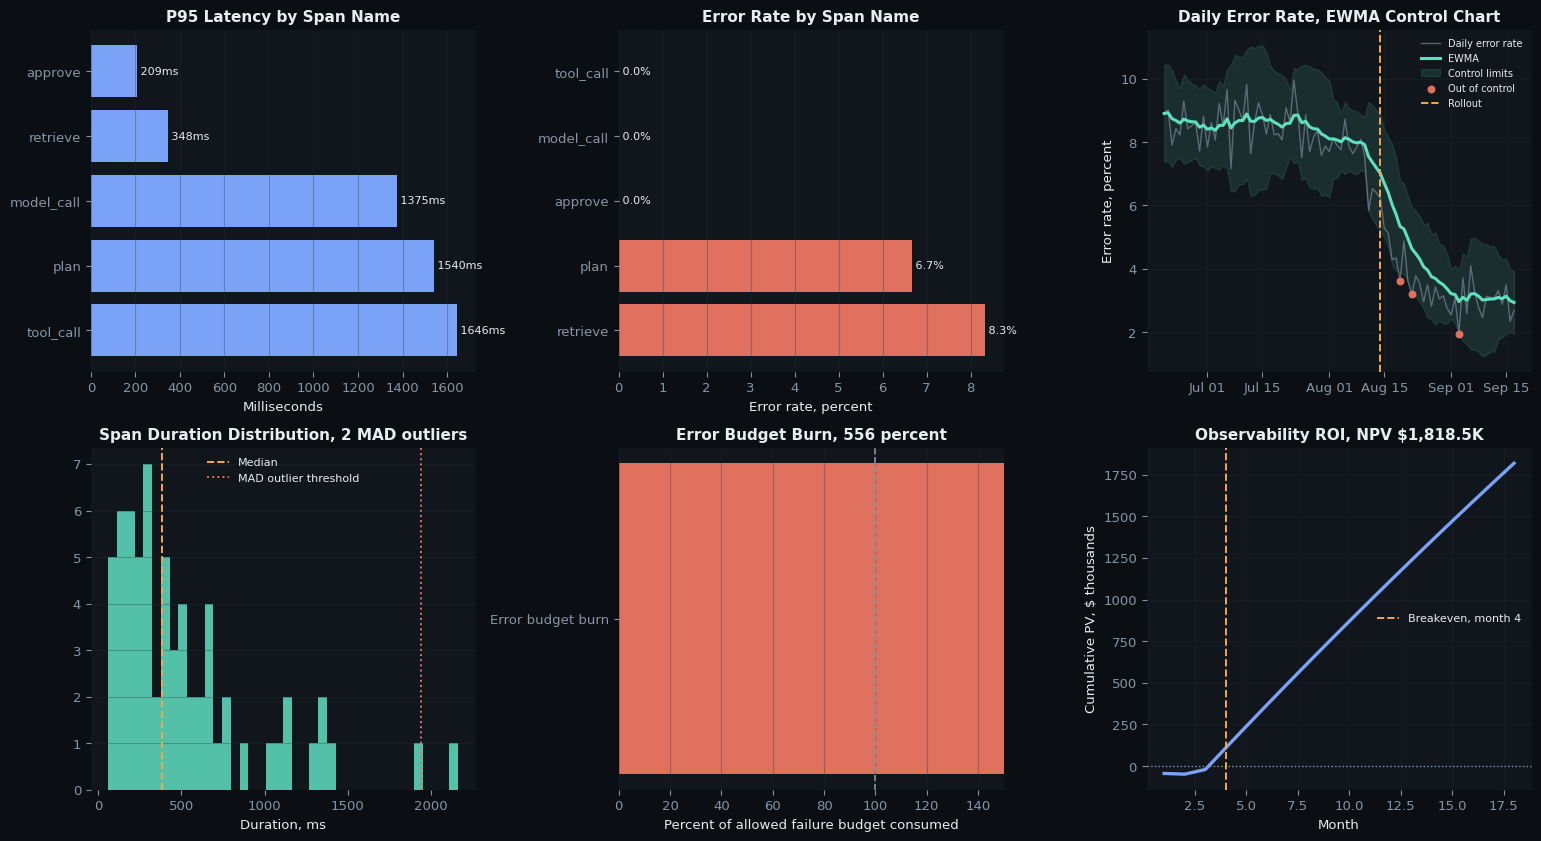

In [12]:
BG, PANEL, GRID = "#0b0f14", "#11161d", "#232a34"
FG, MUTED = "#e8edf2", "#8894a3"
ACCENT, ACCENT2, ACCENT3, ACCENT4, ACCENT5 = "#5ee0c0", "#f2a94f", "#7aa2f7", "#e0715e", "#c792ea"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "axes.edgecolor": GRID,
    "axes.labelcolor": FG, "text.color": FG, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "font.size": 9.5, "axes.titleweight": "bold", "axes.titlesize": 11,
})

fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.5))

ax = axes[0, 0]
sorted_rollup = trace_rollup.sort_values("p95_latency_ms", ascending=False)
bars = ax.barh(sorted_rollup["name"], sorted_rollup["p95_latency_ms"], color=ACCENT3)
for b, v in zip(bars, sorted_rollup["p95_latency_ms"]):
    ax.text(v, b.get_y() + b.get_height() / 2, f" {v:.0f}ms", va="center", fontsize=8, color=FG)
ax.set_title("P95 Latency by Span Name")
ax.set_xlabel("Milliseconds")
ax.grid(alpha=0.3, axis="x")

ax = axes[0, 1]
sorted_err = trace_rollup.sort_values("error_rate", ascending=False)
bars = ax.barh(sorted_err["name"], sorted_err["error_rate"] * 100, color=ACCENT4)
for b, v in zip(bars, sorted_err["error_rate"] * 100):
    ax.text(v, b.get_y() + b.get_height() / 2, f" {v:.1f}%", va="center", fontsize=8, color=FG)
ax.set_title("Error Rate by Span Name")
ax.set_xlabel("Error rate, percent")
ax.grid(alpha=0.3, axis="x")

ax = axes[0, 2]
dates = pd.to_datetime(daily_metrics["date"])
ax.plot(dates, daily_metrics["error_rate"] * 100, color=MUTED, linewidth=1.0, alpha=0.6, label="Daily error rate")
ax.plot(dates, daily_metrics["error_rate_ewma"] * 100, color=ACCENT, linewidth=2.2, label="EWMA")
ax.fill_between(dates, daily_metrics["error_rate_lower_limit"] * 100,
                 daily_metrics["error_rate_upper_limit"] * 100, color=ACCENT, alpha=0.12, label="Control limits")
oc = daily_metrics[daily_metrics["error_rate_out_of_control"]]
if len(oc):
    ax.scatter(pd.to_datetime(oc["date"]), oc["error_rate"] * 100, color=ACCENT4, zorder=5, s=22, label="Out of control")
rollout_date = dates.iloc[int(w["rollout_day"])]
ax.axvline(rollout_date, color=ACCENT2, linestyle="--", linewidth=1.4, label="Rollout")
ax.set_title("Daily Error Rate, EWMA Control Chart")
ax.set_ylabel("Error rate, percent")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(frameon=False, fontsize=7, loc="upper right")
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.hist(fixture["duration_ms"], bins=40, color=ACCENT, alpha=0.85)
med = fixture["duration_ms"].median()
outlier_vals = quality["spans_with_mad"].loc[quality["spans_with_mad"]["mad_z"] > 3.5, "duration_ms"]
ax.axvline(med, color=ACCENT2, linestyle="--", linewidth=1.4, label="Median")
if len(outlier_vals):
    ax.axvline(outlier_vals.min(), color=ACCENT4, linestyle=":", linewidth=1.4, label="MAD outlier threshold")
ax.set_title(f"Span Duration Distribution, {quality['n_latency_outliers']} MAD outliers")
ax.set_xlabel("Duration, ms")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3, axis="y")

ax = axes[1, 1]
burn = min(quality["error_budget_burn_pct"], 150)
color_gauge = ACCENT if quality["error_budget_burn_pct"] <= 100 else ACCENT4
ax.barh(["Error budget burn"], [burn], color=color_gauge, height=0.5)
ax.axvline(100, color=MUTED, linestyle="--", linewidth=1.2)
ax.set_xlim(0, 150)
ax.set_title(f"Error Budget Burn, {quality['error_budget_burn_pct']:.0f} percent")
ax.set_xlabel("Percent of allowed failure budget consumed")
ax.grid(alpha=0.3, axis="x")

ax = axes[1, 2]
ax.plot(roi["schedule"]["month"], roi["schedule"]["cumulative_pv_usd"] / 1000, color=ACCENT3, linewidth=2.4)
ax.axhline(0, color=MUTED, linestyle=":", linewidth=1.0)
if roi["breakeven_month"] is not None:
    ax.axvline(roi["breakeven_month"], color=ACCENT2, linestyle="--", linewidth=1.4,
               label=f"Breakeven, month {roi['breakeven_month']}")
    ax.legend(frameon=False, fontsize=8)
ax.set_title(f"Observability ROI, NPV ${roi['npv_usd']/1000:,.1f}K")
ax.set_xlabel("Month")
ax.set_ylabel("Cumulative PV, $ thousands")
ax.grid(alpha=0.3)

for row in axes:
    for a in row:
        for s in a.spines.values():
            s.set_visible(False)

fig.tight_layout()
fig.savefig(OUT / "six_panel_dashboard.svg", facecolor=BG, bbox_inches="tight")
fig.savefig(OUT / "six_panel_dashboard.png", dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()

## 8. Article metrics and exports

In [13]:
article_metrics = {
    "traces": quality["n_traces"],
    "spans": quality["n_spans"],
    "observed_success_percent": quality["observed_success_rate_pct"],
    "error_budget_burn_pct": quality["error_budget_burn_pct"],
    "n_latency_outliers": quality["n_latency_outliers"],
    "pre_rollout_error_rate_trend_per_day": pre_slope,
    "post_rollout_error_rate_trend_per_day": post_slope,
    "roi_npv_usd": roi["npv_usd"],
    "roi_breakeven_month": roi["breakeven_month"],
    "vendor_price_at_20m_spans_usd": float(
        pricing_table.set_index("volume_million_spans_per_month").loc[20, "monthly_revenue_usd"]
    ),
}
pd.DataFrame([article_metrics]).to_csv(OUT / "article_metrics.csv", index=False)
print(json.dumps(article_metrics, indent=2, default=str))

files_written = [
    "source_data.csv", "model_assumptions.csv", "span_fixture.csv", "trace_rollup.csv",
    "field_completeness.csv", "slo_receipt.csv", "daily_metrics_timeseries.csv",
    "incident_cost_schedule.csv", "roi_schedule.csv", "pricing_scenarios.csv",
    "six_panel_dashboard.svg", "six_panel_dashboard.png", "article_metrics.csv",
]
yc.write_manifest(OUT, files_written, RUN_ID, extra={"source_data_sha256": source_hash})
receipt = yc.write_validation_receipt(OUT, validation, RUN_ID, source_hash)
print("Validation receipt status:", receipt["status"])

{
  "traces": 12,
  "spans": 65,
  "observed_success_percent": 83.33333333333334,
  "error_budget_burn_pct": 555.5555555555549,
  "n_latency_outliers": 2,
  "pre_rollout_error_rate_trend_per_day": -0.0002446672284840283,
  "post_rollout_error_rate_trend_per_day": -0.0005924632367044786,
  "roi_npv_usd": 1818472.2250632893,
  "roi_breakeven_month": 4,
  "vendor_price_at_20m_spans_usd": 3060.0
}
Validation receipt status: PASS


## 9. Dashboard, dark, self contained HTML

In [14]:
kpis = [
    {"label": "Traces, Spans", "value": f"{quality['n_traces']}, {quality['n_spans']}", "sub": "Synthetic fixture, seeded", "accent": True},
    {"label": "Observed Success Rate", "value": f"{quality['observed_success_rate_pct']:.1f}%", "sub": f"SLO target {float(w['slo_target_success_rate']):.0%}"},
    {"label": "ROI NPV, 18 months", "value": f"${roi['npv_usd']/1000:,.1f}K", "sub": f"Breakeven month {roi['breakeven_month']}"},
    {"label": "Error Rate Trend Post Rollout", "value": f"{post_slope*100:.4f} pts per day", "sub": "Negative is improving"},
]
panels = [
    {"title": "Latency, Errors, Time Series and ROI, Six Panel View", "image_path": OUT / "six_panel_dashboard.png", "full": True,
     "note": "OpenTelemetry trace and span structure is sourced documentation. The trace fixture, daily time series, and every dollar figure are labeled model assumptions, not real production or financial data."},
]
html = yc.render_dashboard(
    eyebrow="Technology Tutorial, Agent Observability",
    title="Agent Trace Quality, SLO and ROI Dashboard",
    intro_html=(
        "Deterministic synthetic trace fixture scored for completeness, latency and error rate, extended with a "
        "90 day daily time series, an EWMA statistical process control chart, and a discounted ROI model that "
        "turns fewer incidents into dollars. Trace and span structure follows OpenTelemetry documentation, "
        "every dollar figure lives in model_assumptions.csv as an editable input."
    ),
    kpis=kpis,
    panels=panels,
    checks=validation,
    footer_html=(
        f"Sources: OpenTelemetry GenAI semantic conventions, OpenTelemetry traces overview, NIST AI RMF. "
        f"Generated {datetime.now(timezone.utc).isoformat()}. Run ID: {RUN_ID}. Validation status: {receipt['status']}."
    ),
)
(OUT / "interactive_dashboard.html").write_text(html, encoding="utf-8")
yc.write_manifest(OUT, files_written + ["interactive_dashboard.html"], RUN_ID, extra={"source_data_sha256": source_hash})
print("Dashboard written to", OUT / "interactive_dashboard.html")

Dashboard written to /home/claude/yariverse/03_technology_tutorial_agent_observability/notebook_output/interactive_dashboard.html


## 10. A way money can be made

Two separate business models sit on top of the same trace data.

Buyer side, cost avoidance. Every failed trace has some probability of
escalating into a real incident. The incident_cost_model() function above
prices that out: expected incidents per day times a fully loaded incident
cost, compared before and after the simulated rollout. Once the
observability pipeline exists, engineers also debug faster because the
trace is the receipt instead of a guess, which is the debug_savings_usd
term. Rolling both into observability_roi() produces a standard
discounted cash flow: the one time engineering cost is the initial
outlay, the monthly avoided incident cost plus debug savings minus the
ongoing tooling bill is the monthly net cash flow, and the breakeven
month is the first month the cumulative present value crosses zero. That
is the same shape of argument a platform or SRE team should bring to a
budget conversation, with the assumptions visible instead of buried in a
slide.

Vendor side, usage based pricing. pricing_tiers() models a simple volume
discounted price per million spans ingested, the way most observability
vendors actually charge. The pricing_scenarios.csv table shows monthly
revenue at a few illustrative volume levels, from a single small agent
team to a large multi team deployment. The interesting monetization lever
here is not the sticker price, it is which volume tier a customer's
actual agent traffic lands in, since that is what determines whether the
product feels cheap at small scale and fair at large scale, or the
reverse.

Both models are illustrative. Replace the dollar assumptions in
model_assumptions.csv with a real cost of incident, a real engineer rate,
and a real observed error rate before using either number in an actual
budget or pricing conversation.

## 11. What could go right, moving forward

The time series above is built around one honest possibility: the
rollout works. The post rollout regime in simulate_daily_metrics() uses a
lower error rate and lower p95 latency than the pre rollout regime, and
the EWMA control chart is there specifically to catch the moment that
improvement either sticks or reverts, rather than assuming it sticks by
default.

If the rollout goes well, three things should show up in the data, in
order. First, the daily error rate EWMA should cross below the pre
rollout baseline within a week or two of the rollout date, since the
logistic transition in the simulation is intentionally fast rather than
a multi month fade. Second, the count of MAD flagged latency outliers per
week should drop, because a real instrumentation project usually finds
and fixes the handful of pathological retries or oversized tool calls
that were dragging the tail. Third, the ROI cumulative present value line
should cross zero at or before the modeled breakeven month, since that is
the point where avoided incident cost plus debug time saved has paid back
the upfront engineering cost.

Two concrete next steps would strengthen the model rather than just
decorate it. Replace the single fixed incident_rate_per_failed_trace
assumption with a distribution fit from real support ticket or page data,
since that single number currently carries a lot of the financial
conclusion. Second, extend ewma_control_chart() to run on p95 latency as
well as error rate, since a latency regression can burn user trust well
before it burns the error budget.

## Run this project
```
jupyter nbconvert --to notebook --execute pipeline.ipynb
```
A PASS status in validation_receipt.json means the evidence labels,
calculations, output files and artifact hashes agree for this run. This
is an educational analytical model over synthetic telemetry and
illustrative financial assumptions, not a production monitoring system
and not a real ROI number.